In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('../data/q2_customers.csv')
df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Important
K-Means uses distance-based calculations. Features with larger values (e.g., annual spend) would dominate smaller ones (e.g., visits per month). Scaling ensures all features contribute equally.


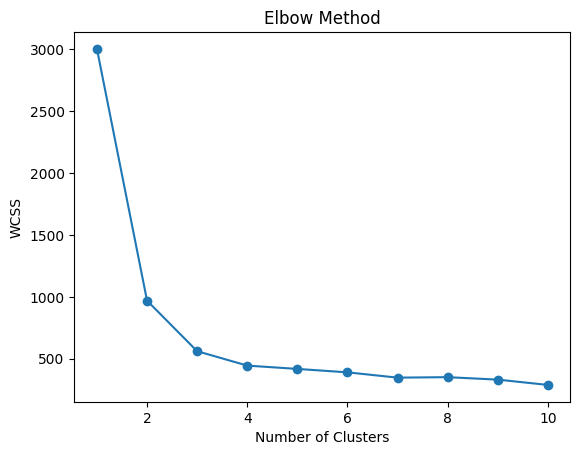

In [4]:
wcss = []

for i in range(1, 11):
   kmeans = KMeans(n_clusters=i, random_state=42)
   kmeans.fit(scaled_df)
   wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


### Optimal K
The elbow appears around K = 3 or 4 where the rate of decrease slows. We select K = 3 for clear segmentation.


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_df)

df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [6]:
centroids = pd.DataFrame(
   scaler.inverse_transform(kmeans.cluster_centers_),
   columns=df.columns[:-1]
)

centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation
- Cluster 0: Low spenders, infrequent visits
- Cluster 1: High spenders, frequent shoppers
- Cluster 2: Moderate customers with average behavior


In [7]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']


In [8]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [9]:
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
loadings


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

PC1 captures spending and purchase behavior, while PC2 captures recency and visit frequency differences.


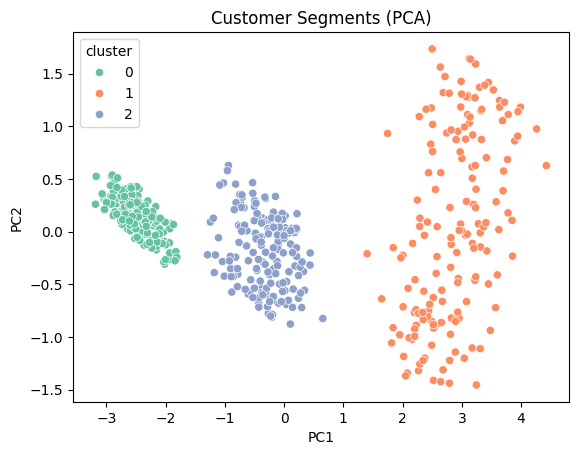

In [10]:
sns.scatterplot(
   x='PC1', y='PC2',
   hue='cluster',
   data=pca_df,
   palette='Set2'
)

plt.title("Customer Segments (PCA)")
plt.show()
